# VAC : Term-End Project < PulsePredict >

In [3]:
# PulsePredict : Intelligent Heart Risk Assessment Model
### Serializing/save the model data
## import packages, datasets N fit the model
# untill prediction step --> it'll do by app.py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Regression DataSet
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier              ### for categorical dataset
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor                ### for continous dataset
from sklearn.metrics import r2_score

### Train test & Standarized data
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler



HeartHealth = pd.read_csv("E:\\Project_adv\\PulsePredict\\lpk_heartdataset.csv")
HeartHealth.head()

,Age,Sex,Chest_Pain_Type,Resting_Blood_Pressure,Cholesterol,Fasting_Blood_Sugar,Max_Heart_Rate,Smoking,Alcohol_Consumption,BMI,Stress_Level,Family_History,Diabetes,Physical_Activity,Heart_Attack_Risk
0,58,0,0,130,215,0,111,0,1,31.5,6,0,0,2,58
1,71,1,2,138,271,0,115,0,0,31.3,2,0,0,1,63
2,48,1,3,112,236,0,158,1,1,32.7,1,0,0,3,62
3,34,0,1,126,202,1,141,0,0,26.6,8,1,0,4,53
4,62,0,2,162,259,1,126,0,0,30.9,8,0,1,2,71


In [4]:
HeartHealth.corr()

,Age,Sex,Chest_Pain_Type,Resting_Blood_Pressure,Cholesterol,Fasting_Blood_Sugar,Max_Heart_Rate,Smoking,Alcohol_Consumption,BMI,Stress_Level,Family_History,Diabetes,Physical_Activity,Heart_Attack_Risk
Age,1.000000,0.032516,-0.011081,0.610637,0.655599,0.120454,-0.798055,0.076606,0.042135,0.419865,-0.038196,0.008615,0.189755,-0.120238,0.750940
Sex,0.032516,1.000000,0.031806,0.040656,0.150827,-0.077132,-0.028575,0.039400,0.033574,0.067054,0.010971,0.015835,-0.015307,-0.001585,0.062217
Chest_Pain_Type,-0.011081,0.031806,1.000000,-0.024701,0.027706,-0.027905,-0.000250,-0.040822,-0.005992,-0.009293,-0.022886,0.027220,0.029702,0.022415,0.198607
Resting_Blood_Pressure,0.610637,0.040656,-0.024701,1.000000,0.416707,0.042882,-0.528010,0.057283,0.053509,0.256816,0.041438,-0.016423,0.077367,-0.087931,0.519180
Cholesterol,0.655599,0.150827,0.027706,0.416707,1.000000,0.057605,-0.548083,0.015574,0.022896,0.286813,-0.012427,-0.000258,0.145288,-0.053362,0.548495
Fasting_Blood_Sugar,0.120454,-0.077132,-0.027905,0.042882,0.057605,1.000000,-0.120466,0.065571,0.026247,0.196753,-0.015904,0.119035,0.533157,-0.110035,0.293192
Max_Heart_Rate,-0.798055,-0.028575,-0.000250,-0.528010,-0.548083,-0.120466,1.000000,-0.037979,-0.010925,-0.354547,0.004817,0.026788,-0.148245,0.204897,-0.650526
Smoking,0.076606,0.039400,-0.040822,0.057283,0.015574,0.065571,-0.037979,1.000000,0.239525,0.245998,0.018170,0.053517,0.116803,-0.090219,0.371702
Alcohol_Consumption,0.042135,0.033574,-0.005992,0.053509,0.022896,0.026247,-0.010925,0.239525,1.000000,0.119531,0.061985,0.007692,0.031065,-0.061757,0.227853
BMI,0.419865,0.067054,-0.009293,0.256816,0.286813,0.196753,-0.354547,0.245998,0.119531,1.000000,-0.005760,0.061813,0.312693,-0.369615,0.635537


#### Data clean

In [5]:
# Data cleaning - isnull & outlier

HeartHealth.isnull().sum(axis=0)

Age                       0
Sex                       0
Chest_Pain_Type           0
Resting_Blood_Pressure    0
Cholesterol               0
Fasting_Blood_Sugar       0
Max_Heart_Rate            0
Smoking                   0
Alcohol_Consumption       0
BMI                       0
Stress_Level              0
Family_History            0
Diabetes                  0
Physical_Activity         0
Heart_Attack_Risk         0
dtype: int64

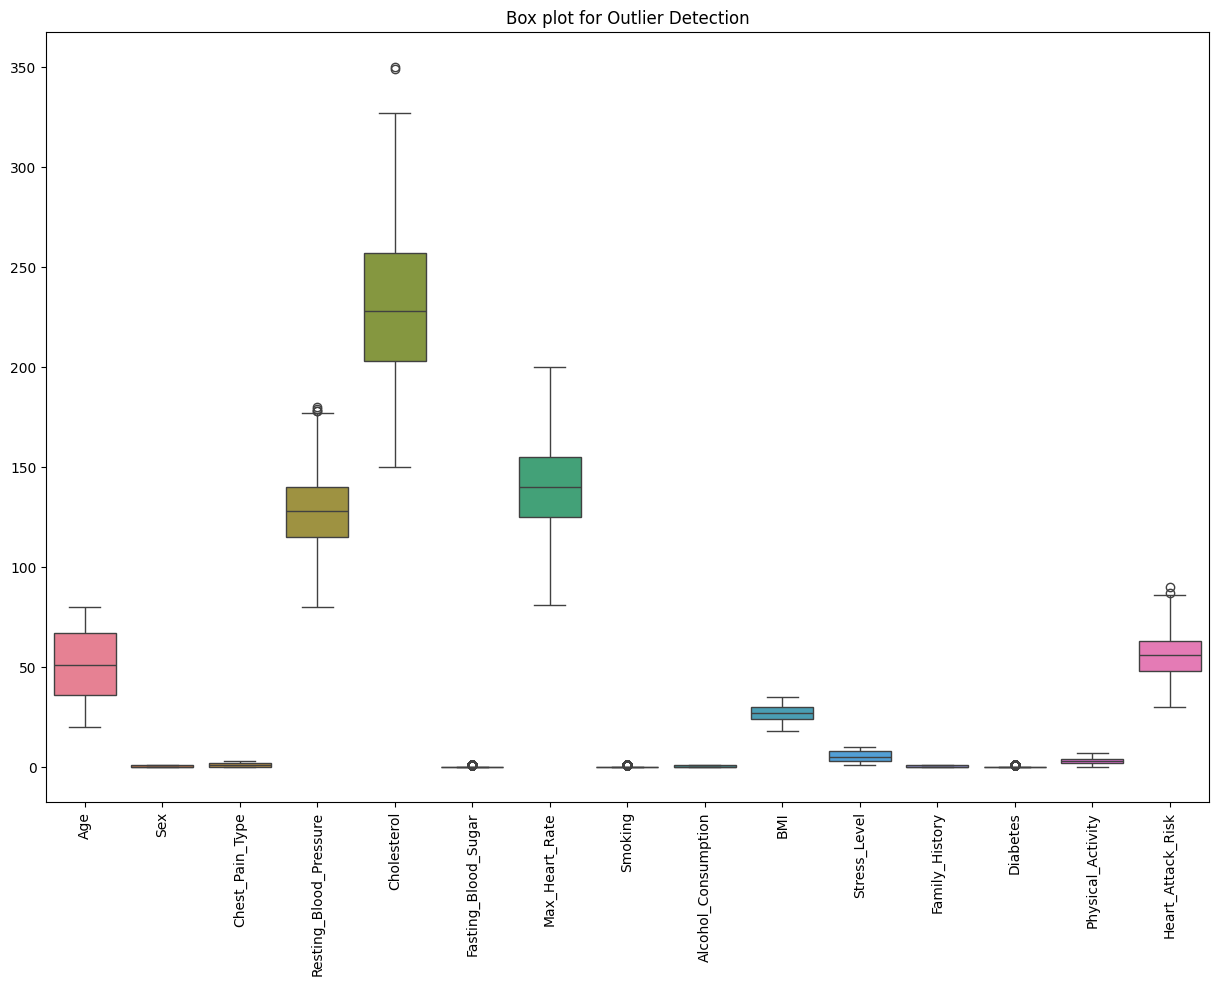

In [6]:
plt.figure(figsize=(15, 10))
sns.boxplot(data=HeartHealth)
plt.title("Box plot for Outlier Detection")
plt.xticks(rotation=90)
plt.show()

In [7]:
HeartHealth.columns

Index(['Age', 'Sex', 'Chest_Pain_Type', 'Resting_Blood_Pressure',
       'Cholesterol', 'Fasting_Blood_Sugar', 'Max_Heart_Rate', 'Smoking',
       'Alcohol_Consumption', 'BMI', 'Stress_Level', 'Family_History',
       'Diabetes', 'Physical_Activity', 'Heart_Attack_Risk'],
      dtype='str')

In [8]:
### Outlier Treatment
list_colmn = ['Age', 'Sex', 'Chest_Pain_Type', 'Resting_Blood_Pressure',
       'Cholesterol', 'Fasting_Blood_Sugar', 'Max_Heart_Rate', 'Smoking',
       'Alcohol_Consumption', 'BMI', 'Stress_Level', 'Family_History',
       'Diabetes', 'Physical_Activity', 'Heart_Attack_Risk']

### if outlier exist so replace the lb with 10th %ile N ub with 90th %ile
for i in list_colmn:
    per_90 = np.percentile(HeartHealth[i], 90)
    per_10 = np.percentile(HeartHealth[i], 10)

    HeartHealth[i] = np.where(HeartHealth[i]>per_90, per_90, HeartHealth[i])
    HeartHealth[i] = np.where(HeartHealth[i]<per_10, per_10, HeartHealth[i])

#### EDA

In [9]:
# EDA
HeartHealth.describe()

,Age,Sex,Chest_Pain_Type,Resting_Blood_Pressure,Cholesterol,Fasting_Blood_Sugar,Max_Heart_Rate,Smoking,Alcohol_Consumption,BMI,Stress_Level,Family_History,Diabetes,Physical_Activity,Heart_Attack_Risk
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.00000,1000.000000,1000.000000,1000.000000
mean,50.933000,0.483000,1.464000,127.713000,229.839000,0.204000,140.020000,0.185000,0.252000,27.169600,5.44500,0.26400,0.159000,3.103000,56.014000
std,16.621395,0.499961,1.126043,15.470034,33.708624,0.403171,17.239455,0.388492,0.434379,3.596487,2.93182,0.44102,0.365859,1.351376,8.967565
min,26.000000,0.000000,0.000000,104.000000,179.000000,0.000000,114.000000,0.000000,0.000000,21.790000,1.00000,0.00000,0.000000,1.000000,43.000000
25%,36.000000,0.000000,0.000000,115.000000,203.000000,0.000000,125.000000,0.000000,0.000000,24.100000,3.00000,0.00000,0.000000,2.000000,48.000000
50%,51.000000,0.000000,1.000000,128.000000,228.000000,0.000000,140.000000,0.000000,0.000000,27.200000,5.00000,0.00000,0.000000,3.000000,56.000000
75%,67.000000,1.000000,2.000000,140.000000,257.000000,0.000000,155.000000,0.000000,1.000000,30.300000,8.00000,1.00000,0.000000,4.000000,63.250000
max,75.000000,1.000000,3.000000,152.000000,284.000000,1.000000,166.000000,1.000000,1.000000,32.800000,10.00000,1.00000,1.000000,5.000000,70.100000


Text(0.5, 0, 'Chol, BP, BMI')

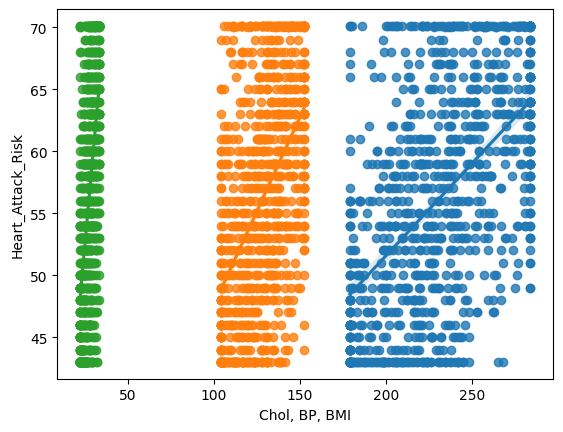

In [10]:
sns.regplot(x='Cholesterol', y='Heart_Attack_Risk', data=HeartHealth)
sns.regplot(x='Resting_Blood_Pressure', y='Heart_Attack_Risk', data=HeartHealth)
sns.regplot(x='BMI', y='Heart_Attack_Risk', data=HeartHealth)
plt.xlabel("Chol, BP, BMI")

<Axes: xlabel='Max_Heart_Rate', ylabel='Heart_Attack_Risk'>

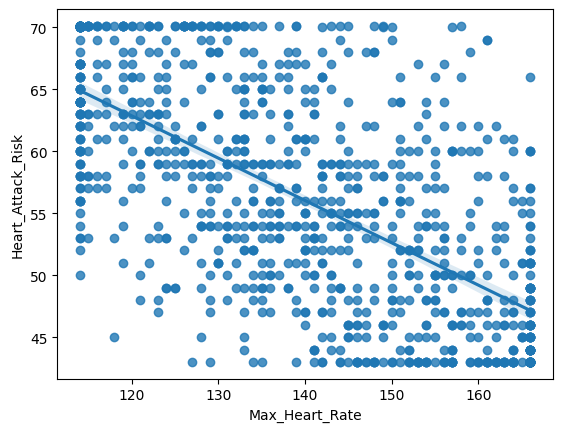

In [11]:
sns.regplot(x='Max_Heart_Rate', y='Heart_Attack_Risk', data=HeartHealth)
### -ve correlation

#### Feature Engineering

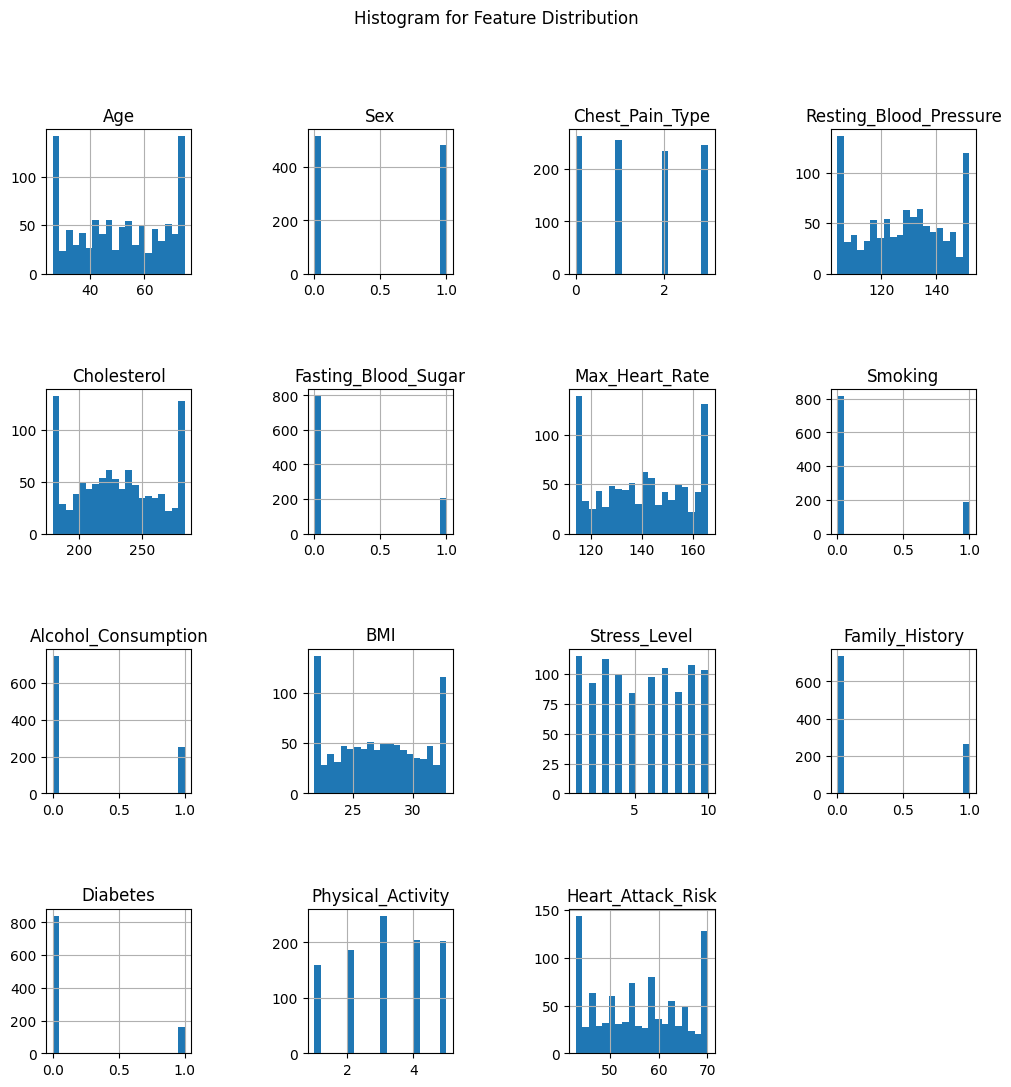

Index(['Age', 'Sex', 'Chest_Pain_Type', 'Resting_Blood_Pressure',
       'Cholesterol', 'Fasting_Blood_Sugar', 'Max_Heart_Rate', 'Smoking',
       'Alcohol_Consumption', 'BMI', 'Stress_Level', 'Family_History',
       'Diabetes', 'Physical_Activity', 'Heart_Attack_Risk'],
      dtype='str')

In [12]:
HeartHealth.hist(figsize=(12, 12), bins=20)
plt.suptitle("Histogram for Feature Distribution")
plt.subplots_adjust(hspace=0.8 , wspace=0.8)
plt.show()
HeartHealth.columns

#### Define & Train Model

In [13]:
### Model trains with data
x = HeartHealth[['Age', 'Sex', 'Chest_Pain_Type', 'Resting_Blood_Pressure',
       'Cholesterol', 'Fasting_Blood_Sugar', 'Max_Heart_Rate', 'Smoking',
       'Alcohol_Consumption', 'BMI', 'Stress_Level', 'Family_History',
       'Diabetes', 'Physical_Activity']] ### inputs records
y = HeartHealth['Heart_Attack_Risk']  ### target record

In [14]:
### Train test split

xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.25, random_state=42)

#### Standarized Data

In [15]:
### Data standardization

scaler = StandardScaler()
xtrain = scaler.fit_transform(xtrain)
xtest = scaler.transform(xtest)


xtrain_scaled = scaler.fit_transform(xtrain)
xtest_scaled = scaler.transform(xtest)

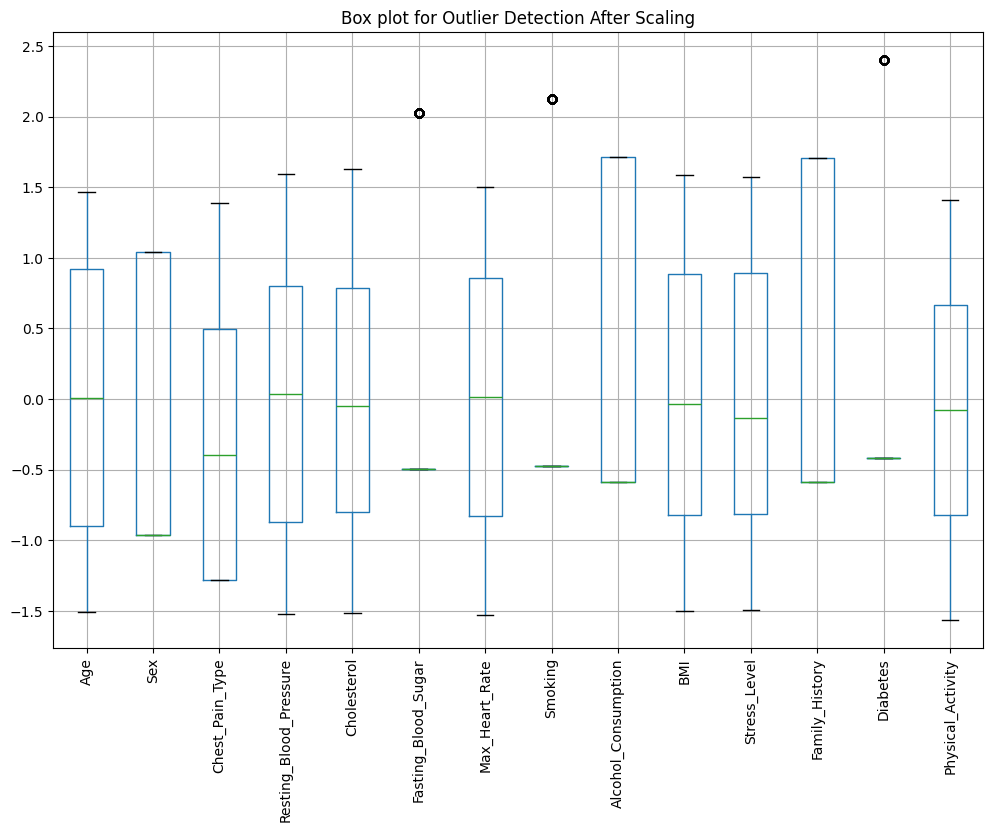

In [16]:

xtrain_scaled_df = pd.DataFrame(xtrain_scaled, columns=x.columns)
plt.figure(figsize=(12, 8))
xtrain_scaled_df.boxplot()
plt.xticks(rotation=90)
plt.title("Box plot for Outlier Detection After Scaling")
plt.show()

#### Via ensemble learning rfregressor

In [17]:
rfmodel = RandomForestRegressor(max_depth=5,
                                    random_state=42,
                                    max_leaf_nodes=5,
                                    min_samples_split=3)    ### bagging  ensemble
abmodel = AdaBoostRegressor(n_estimators=2,
                                 learning_rate=5,
                                 random_state=42)  

In [18]:
rfmodel.fit(xtrain, ytrain)
abmodel.fit(xtrain, ytrain)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.If ``None``, then the base estimator is:class:`~sklearn.tree.DecisionTreeRegressor` initialized with`max_depth=3`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",2
,"learning_rate learning_rate: float, default=1.0Weight applied to each regressor at each boosting iteration. A higherlearning rate increases the contribution of each regressor. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",5
,"loss loss: {'linear', 'square', 'exponential'}, default='linear'The loss function to use when updating the weights after eachboosting iteration.",'linear'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.In addition, it controls the bootstrap of the weights used to train the`estimator` at each boosting iteration.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [19]:
## cv --> regressor bug

cvRF = cross_val_score(rfmodel, xtrain, ytrain, scoring='neg_mean_squared_error', cv=3)
cvAB = cross_val_score(abmodel, xtrain, ytrain, scoring='neg_mean_squared_error', cv=2)

print("minium -ve :", np.mean(cvRF))

print("minium -ve :", np.mean(cvAB))               ### tooo good ~ - 1cr+ huehuehue... 🤣🤣🤣

minium -ve : -24.53508674521233
minium -ve : -43.185865149578376


In [20]:
### predict
RF_pred= rfmodel.predict(xtest)
AB_pred = abmodel.predict(xtest)

print("accuracy of RandomForestClassifier    : ", r2_score(ytest, RF_pred))
print("accuracy of AdaBoostClassifier    : ", r2_score(ytest, AB_pred))

accuracy of RandomForestClassifier    :  0.7021681802615847
accuracy of AdaBoostClassifier    :  0.6055871327110374


In [21]:
### Save the trained model as pkl file
import joblib
import pickle

joblib.dump(rfmodel, "model.pkl")

['model.pkl']

#### Hyper Parameter Tuning & CV

In [22]:
### Hyper Parameters Tuning & cv via GridSearchCV
Parameters  = {'criterion': ['squared_error'],
        'max_depth': [10],
        'max_features': [None],
        'min_samples_leaf': [10],
       'min_samples_split': [5]}

from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
dtmodel = DecisionTreeRegressor()

modelcv = GridSearchCV(dtmodel, param_grid=Parameters, cv=5, scoring='neg_mean_squared_error', error_score='raise')

In [23]:
### Train the model
 
model = modelcv.fit(xtrain, ytrain)
modelfit = dtmodel.fit(xtrain, ytrain)

In [24]:
### Trained model given best params_ r 
{'criterion': 'squared_error',
 'max_depth': 10,
 'max_features': None,
 'min_samples_leaf': 10,
 'min_samples_split': 5}
modelcv.best_params_

{'criterion': 'squared_error',
 'max_depth': 10,
 'max_features': None,
 'min_samples_leaf': 10,
 'min_samples_split': 5}

#### Prediction & Accuracy Without Parameter Tuning

In [25]:
### Prediction, CV and acuracy
from sklearn.model_selection import cross_val_score

mse = cross_val_score(modelfit,xtrain, ytrain, scoring='neg_mean_squared_error', cv=5)
np.mean(mse)  # Average Error

np.float64(-23.43562666666668)

In [26]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

y_pred = modelfit.predict(xtest)

r2 = r2_score(ytest, y_pred)
mae = mean_absolute_error(ytest, y_pred)
mse = mean_squared_error(ytest, y_pred)
rmse = mse ** 0.5

print("R2 Score (How better is model):", r2)
print("MAE (average errors):", mae)
print("MSE :", mse)
print("RMSE :", rmse)

R2 Score (How better is model): 0.7194662664387008
MAE (average errors): 3.408800000000003
MSE : 22.36448000000001
RMSE : 4.729109852815856


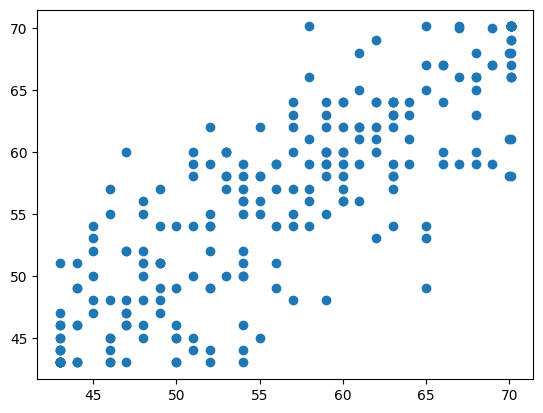

In [27]:
### plot bw ytest and ypred - is linear or not
plt.scatter(ytest, y_pred) ## almost linear now ...

#### Prediction & Accuracy

In [28]:
### Prediction, CV and acuracy
from sklearn.model_selection import cross_val_score

mse = cross_val_score(model,xtrain, ytrain, scoring='neg_mean_squared_error', cv=5)
np.mean(mse)  # Average Error without parameter tuning mse value is -44.5


np.float64(-20.61932491173978)

In [29]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

y_pred = model.predict(xtest)

r2 = r2_score(ytest, y_pred)
mae = mean_absolute_error(ytest, y_pred)
mse = mean_squared_error(ytest, y_pred)
rmse = mse ** 0.5

print("R2 Score (How better is model):", r2)
print("MAE (average errors):", mae)
print("MSE :", mse)
print("RMSE :", rmse)

# “After applying hyperparameter tuning, the model
# performance improved significantly. The R² score increased
# from 0.53 to 0.64, while error metrics such as MAE and RMSE
# decreased. This indicates that the optimized model provides 
# more accurate and reliable predictions.”



R2 Score (How better is model): 0.700143168122901
MAE (average errors): 3.6702506461082796
MSE : 23.904940180441404
RMSE : 4.88926785730148


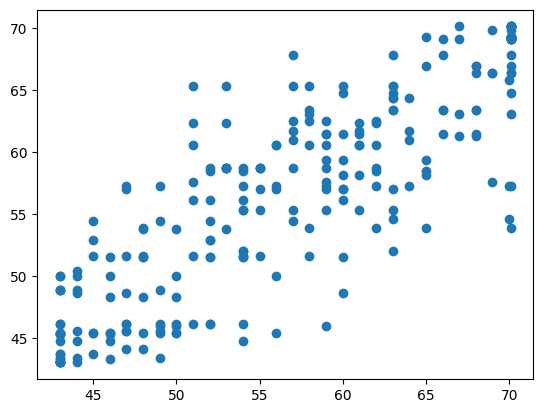

In [30]:
### plot bw ytest and ypred - is linear or not
plt.scatter(ytest, y_pred) ## almost linear now ...

#### Feature Importence

In [31]:
feature_importances = dtmodel.feature_importances_
features = x.columns 
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

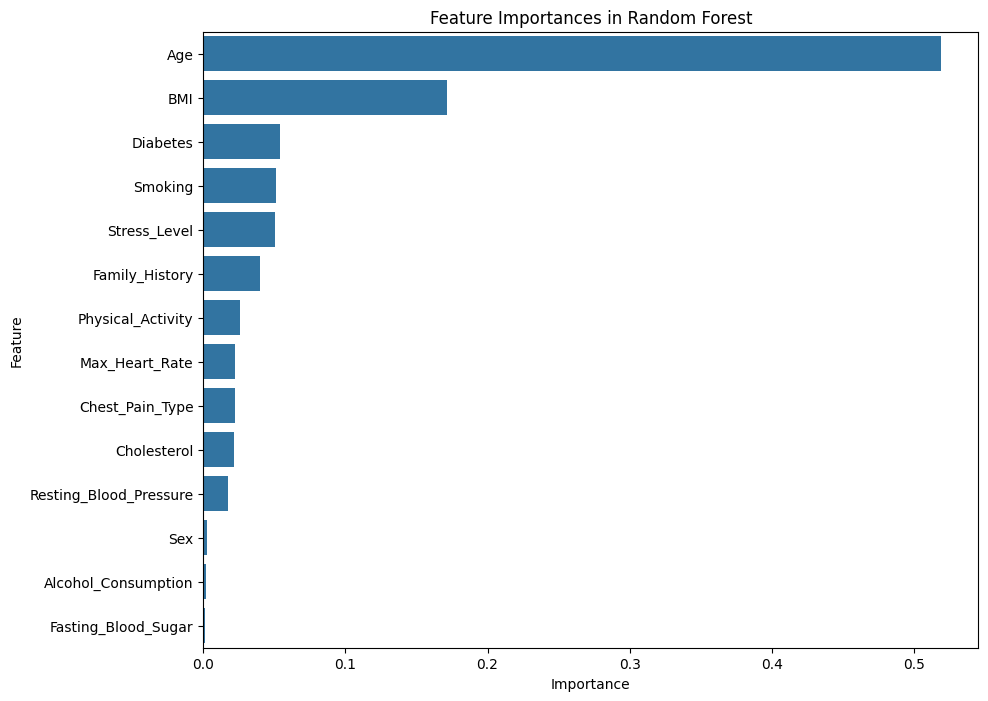

In [32]:
### Importance of features
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title("Feature Importances in Random Forest")
plt.show()